# Goals

* Assessement of SKU level modeling (OLS)
* including lagged variables

# Libraries

In [838]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [839]:
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid
import statsmodels.formula.api as smf

# Raw data

In [840]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"]="/Users/wphong/Desktop/Zinus/market-analysis-project-91130-f7b373249865.json"

import google.auth 

from google.cloud import bigquery

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [841]:
sql = """
select * from wook.fact_amz_mkt_all;
"""
# select zinus_sku_cd as sku, collection from `market-analysis-project-91130.meta.erp_sku_collection_220330`

df = bqclient.query(sql).to_dataframe()
df = df.drop_duplicates()
df

,asin,prdct_title,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,zinus_sku,collection,profile,size,yr_wk,rvw_cnt,star12_cnt,star12_ratio
0,B088N8J71Y,Beige Swatch,0.00,24,<NA>,0.000000,4,6.000000,0.000000,FSLTD-BG,None,None,None,202024,<NA>,<NA>,NaN
1,B088NP3K7P,Soft Grey Swatch,0.00,2,<NA>,0.000000,2,1.000000,0.000000,FB5432G,None,None,None,202029,<NA>,<NA>,NaN
2,B07HYVX2NZ,"Zinus Alto Table, White",220.58,1,436,220.580000,39,0.025641,0.000000,OLB-DT-AW47,OLB DT,None,None,202052,<NA>,<NA>,NaN
3,B07GGF5RFF,"Zinus Josh, Sofa, Beige",8331.46,25,72,333.258400,10703,0.002336,0.000000,SSTD-BG,SSTD,None,None,202030,4,2,0.5
4,B07GGF5RFF,"Zinus Josh, Sofa, Beige",25999.62,81,69,320.982963,15518,0.005220,0.000000,SSTD-BG,SSTD,None,None,202029,4,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174094,B07W8JQ5KR,Zinus Jared 14 Inch Metal Adjustable Bed Frame...,0.00,0,2160,NaN,237,0.000000,0.040486,ADB-14Q,ADB,14 Inch,Queen,202126,<NA>,<NA>,NaN
174095,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,0.00,0,145,NaN,47,0.000000,0.078431,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202144,<NA>,<NA>,NaN
174096,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,5.08,0,363,NaN,277,0.000000,0.051370,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202150,<NA>,<NA>,NaN
174097,B07VWL116L,Zinus Italian Made 12 Inch Olive Oil Pocket Sp...,0.00,0,308,NaN,176,0.000000,0.078534,ITA-OLIVE-12Q,OLIVE OIL,12 inch,Queen,202204,<NA>,<NA>,NaN


In [842]:
df['year_week']=[pd.to_datetime(str(yr_wk)+'0',format="%Y%U%w") for yr_wk in df.yr_wk]
df.drop('yr_wk',axis=1,inplace=True)
df.sort_values(by=['year_week','profile'],inplace=True)

In [843]:
df.reset_index(drop=True,inplace=True)

In [844]:
df.head()

,asin,prdct_title,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,zinus_sku,collection,profile,size,rvw_cnt,star12_cnt,star12_ratio,year_week
0,B073HF47HX,Zinus Green Tea Cooling Gel Memory Foam Mattre...,1024.75,26,133,39.413462,1025,0.025366,0.000965,OLB-MGT-150F,OLB MGT,1.5 Inch,Full,1,0,0.0,2020-01-05
1,B073HFL96Z,Zinus Green Tea Cooling Gel Memory Foam Mattre...,580.93,7,246,82.990000,330,0.021212,0.005970,OLB-MGT-150K,OLB MGT,1.5 Inch,King,1,0,0.0,2020-01-05
2,B073HFP1KV,Zinus Green Tea Cooling Gel Memory Foam Mattre...,628.41,17,66,36.965294,1120,0.015179,0.006195,OLB-MGT-150T,OLB MGT,1.5 Inch,Twin,<NA>,<NA>,NaN,2020-01-05
3,B073HFRNCL,Zinus Green Tea Cooling Gel Memory Foam Mattre...,701.90,10,143,70.190000,499,0.020040,0.000000,OLB-MGT-150Q,OLB MGT,1.5 Inch,Queen,<NA>,<NA>,NaN,2020-01-05
4,B073JX573H,Zinus 1.5 Inch Swirl Gel Memory Foam Convolute...,1330.25,38,120,35.006579,649,0.058552,0.001538,AZ-SWFT-150F,SWFT,1.5 Inch,Full,2,1,0.5,2020-01-05


In [846]:
df.columns.tolist()

['asin',
 'prdct_title',
 'ord_rev',
 'ord_qty',
 'sale_rank',
 'avg_price',
 'gv',
 'cnvrsn_rate',
 'rep_oos',
 'zinus_sku',
 'collection',
 'profile',
 'size',
 'rvw_cnt',
 'star12_cnt',
 'star12_ratio',
 'year_week']

In [847]:
df.shape

(173989, 17)

## How many ASINs and Collections?

In [848]:
len(df.collection.unique())

347

In [849]:
len(df.asin.unique())

2141

In [850]:
len(df.zinus_sku.unique())

1775

### Every ASINs have collection?

In [851]:
sum(df.collection.isna())

10265

In [852]:
len(df.asin[df.collection.isna()].unique())

375

In [853]:
print('There are ',2141-375,' ASINs with collection label')

There are  1766  ASINs with collection label


In [854]:
df.shape

(173989, 17)

### Remove rows with no collection info

In [855]:
df = df[~df.collection.isna()]

In [856]:
df.shape

(163724, 17)

## How many inches per collection?

In [857]:
num_inch = df_set[['collection','profile']].groupby(['collection']).agg({'profile':pd.Series.nunique})
num_inch

,profile
collection,
ASMP,2
ASMPCH,1
ASMPH,2
BECKY,0
BIFD,2
...,...
WCBFC,0
WDBF,1
WOODROW,0


(array([78.,  0., 57.,  0., 15.,  0.,  8.,  0.,  6.,  1.]),
 array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ]),
 <BarContainer object of 10 artists>)

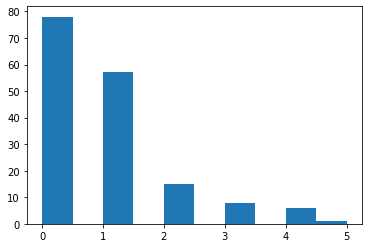

In [858]:
plt.hist(num_inch)

In [859]:
coll_inch = df_set[['collection','profile']].pivot_table(index='collection',columns='profile',aggfunc=np.unique)
coll_inch

profile,1.5 Inch,10 Inch,12 inch,14 Inch,16 Inch,18 Inch,2 Inch,3 Inch,3.5 Inch,4 Inch,5 Inch,5.75 Inch,6 Inch,7 Inch,7.5 Inch,8 Inch,9 Inch
collection,,,,,,,,,,,,,,,,,
ASMP,NaN,"[10 Inch, ASMP]",NaN,"[14 Inch, ASMP]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASMPCH,NaN,NaN,NaN,"[14 Inch, ASMPCH]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASMPH,NaN,"[10 Inch, ASMPH]",NaN,"[14 Inch, ASMPH]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BIFD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[7.5 Inch, BIFD]",NaN,"[9 Inch, BIFD]"
BTCM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"[8 Inch, BTCM]",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SWPBBHG,NaN,NaN,NaN,"[14 Inch, SWPBBHG]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SWPBBHM,NaN,NaN,NaN,"[14 Inch, SWPBBHM]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SWPBBHW,NaN,NaN,NaN,"[14 Inch, SWPBBHW]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Range of date

from Jan. 2020 to Jun. 2022

In [860]:
np.min(df.year_week),np.max(df.year_week)

(Timestamp('2020-01-05 00:00:00'), Timestamp('2022-06-12 00:00:00'))

how many weeks if full records? ==> $128$ points

In [861]:
pd.date_range(start='2020-01-05',end='2022-06-12',freq='W')

DatetimeIndex(['2020-01-05', '2020-01-12', '2020-01-19', '2020-01-26',
               '2020-02-02', '2020-02-09', '2020-02-16', '2020-02-23',
               '2020-03-01', '2020-03-08',
               ...
               '2022-04-10', '2022-04-17', '2022-04-24', '2022-05-01',
               '2022-05-08', '2022-05-15', '2022-05-22', '2022-05-29',
               '2022-06-05', '2022-06-12'],
              dtype='datetime64[ns]', length=128, freq='W-SUN')

## Sample counts

In [862]:
vc_asin = df[['collection','asin']].value_counts()
vc_asin

collection  asin      
OLB ASB     B00R6OXMBC    128
OLB FGM     B01N0VNL1N    128
OLB EBS     B06XJ8NY75    128
            B06XJ939V4    128
            B06XJ9HV4D    128
                         ... 
PFC         B07SGG856Y      3
GOPB        B08G49PLD3      2
PFL         B07SMTKQQM      2
UFHCLG      B099ZFBC41      2
SBF         B00I32G21S      1
Length: 1766, dtype: int64

(array([ 64.,  93.,  99., 118., 136., 133.,  66.,  76.,  97., 884.]),
 array([  1. ,  13.7,  26.4,  39.1,  51.8,  64.5,  77.2,  89.9, 102.6,
        115.3, 128. ]),
 <BarContainer object of 10 artists>)

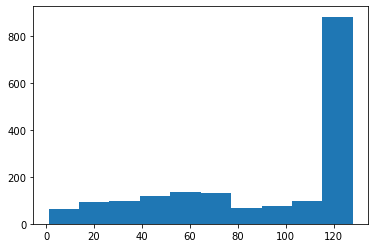

In [863]:
plt.hist(vc_asin)

In [864]:
np.min(vc_asin),np.max(vc_asin)

(1, 128)

In [865]:
vc_asin[vc_asin>120].reset_index()

,collection,asin,0
0,OLB ASB,B00R6OXMBC,128
1,OLB FGM,B01N0VNL1N,128
2,OLB EBS,B06XJ8NY75,128
3,OLB EBS,B06XJ939V4,128
4,OLB EBS,B06XJ9HV4D,128
...,...,...,...
816,OLB DT,B077H7FJLG,121
817,CPBF,B078MQ2D8B,121
818,FRBX,B07KK8JT9K,121
819,SLMC,B07T9K9N71,121


In [866]:
asin_gt_120 = vc_asin[vc_asin>120].reset_index().asin.unique()
asin_gt_120

array(['B00R6OXMBC', 'B01N0VNL1N', 'B06XJ8NY75', 'B06XJ939V4',
       'B06XJ9HV4D', 'B0765DDG9R', 'B071XDLS6L', 'B0721TPYCF',
       'B072N8V583', 'B01BEGS15E', 'B01I5ZLJ3I', 'B01MY87BRW',
       'B01MS26EZ3', 'B01MT3VRFA', 'B01MT3VRHV', 'B01MU5FK81',
       'B01N1X5K70', 'B06XJ8G9T6', 'B01NANZ3HQ', 'B01NANZ5WG',
       'B01NBPG0LU', 'B01NBPG153', 'B01NBPG1QV', 'B01NH0QVM4',
       'B01NH0XWNU', 'B01NH11UG3', 'B072M8JWGR', 'B072M8KWW1',
       'B077H7X2LW', 'B00Q7EPFT4', 'B00Q7EPILO', 'B00Q7EPLM0',
       'B06XJ8L859', 'B06XJ6QZCF', 'B073HG1J25', 'B075F9KTQW',
       'B07FSWDTRT', 'B07FSWYH7R', 'B01N9MKZPJ', 'B073R1DJYT',
       'B075FFTLFV', 'B077YR6JH9', 'B0785N7SY7', 'B0785QHZ8J',
       'B0792GZZHZ', 'B07117CWTR', 'B0716DV2DP', 'B071DQJQ1C',
       'B073R14H7Z', 'B075F9KPQH', 'B076CVHLVQ', 'B06XJ64MLC',
       'B077H7B4PB', 'B077H7HDMR', 'B078TP2CD6', 'B078YGP7Q5',
       'B07JFP8JJS', 'B07JFPRMTP', 'B07JH6HPXC', 'B0765DNGWV',
       'B076CXV5PH', 'B076CTV19W', 'B06XHTZ747', 'B06XH

In [867]:
len(asin_gt_120)

821

$46.5$ % of ASIns are ignored

In [868]:
len(asin_gt_120)/len(df.asin.unique())

0.46489241223103056

## descriptive statistics of having more than 120 samples

In [869]:
df.shape

(163724, 17)

In [870]:
df_sub = df[df.asin.isin(asin_gt_120)]

In [871]:
df_sub.shape

(104698, 17)

**`ord_rev`, `ord_qty`, `avg_price`, `cnvrsn_rate` has negative values**

In [872]:
df_sub.describe()

,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rep_oos,rvw_cnt,star12_cnt,star12_ratio
count,1.046980e+05,104698.000000,103494.000000,93592.000000,104692.000000,95161.000000,97368.000000,41928.000000,41928.000000,41928.000000
mean,1.490644e+04,97.793100,655.979110,174.123385,3566.616351,0.030396,0.062974,3.058314,0.490937,0.169131
std,6.616723e+04,345.080247,940.516135,102.241660,8987.422167,0.191581,0.197904,4.304491,1.057380,0.310199
min,-1.909576e+05,-683.000000,1.000000,-275.620000,0.000000,-2.000000,0.000000,1.000000,0.000000,0.000000
25%,5.423125e+02,4.000000,127.000000,99.025550,235.000000,0.011194,0.000000,1.000000,0.000000,0.000000
50%,2.850420e+03,19.000000,309.000000,155.680000,1130.500000,0.020833,0.000000,2.000000,0.000000,0.000000
75%,1.115340e+04,72.000000,838.000000,226.780000,3510.250000,0.037037,0.015447,3.000000,1.000000,0.242424
max,1.266026e+07,43825.000000,24047.000000,932.247500,871072.000000,49.000000,1.000000,106.000000,30.000000,1.000000


In [873]:
NA_df_sub = dict()
cols = df_sub.columns
for col in cols:
    NA_df_sub[col] = sum(df_sub[col].isna())

In [874]:
NA_df_sub

{'asin': 0,
 'prdct_title': 0,
 'ord_rev': 0,
 'ord_qty': 0,
 'sale_rank': 1204,
 'avg_price': 11106,
 'gv': 6,
 'cnvrsn_rate': 9537,
 'rep_oos': 7330,
 'zinus_sku': 0,
 'collection': 0,
 'profile': 32865,
 'size': 14502,
 'rvw_cnt': 62770,
 'star12_cnt': 62770,
 'star12_ratio': 62770,
 'year_week': 0}

# Replacing NA : app1

* `avg_price` : ffill
* `sale_rank` : ffill
* `cnvrsn_rate` : ffill

* `gv` : 0
* `rep_oos` : 0
* `rvw_cnt` : 0
* `star12_cnt` : 0
* `star12_ratio` : 0

## date range and filling

In [875]:
dt_rg = pd.date_range(start='2020-01-05',end='2022-06-12',freq='W')
dt_rg.name='year_week'

In [876]:
colls_asins = df_sub[['collection','asin']].value_counts().index.tolist()

In [877]:
df_set = pd.DataFrame(columns=df_sub.columns)

for coll_asin in colls_asins:
    tmp_df = pd.DataFrame(index=dt_rg)
    tmp_df = tmp_df.join(df_sub[(df_sub.collection==coll_asin[0]) \
                   & (df_sub.asin==coll_asin[1])].set_index('year_week'))
    tmp_df.sort_values(by='year_week',inplace=True)
    
    collection = tmp_df.collection[0]
    asin = tmp_df.asin[0]
    prdct_title = tmp_df.prdct_title[0]
    zinus_sku = tmp_df.zinus_sku[0]
    profile = tmp_df.profile[0]
    size = tmp_df['size'][0]
    
    tmp_df = tmp_df.resample('W-Sun').mean()
    
    tmp_df[['collection','asin','prdct_title','zinus_sku','profile','size']] = \
            [collection,asin,prdct_title,zinus_sku,profile,size]
    
    tmp_df[['avg_price','sale_rank','cnvrsn_rate']] = \
            tmp_df[['avg_price','sale_rank','cnvrsn_rate']].ffill()
    tmp_df[['gv','rep_oos','rvw_cnt','star12_cnt','star12_ratio']] = \
            tmp_df[['gv','rep_oos','rvw_cnt','star12_cnt','star12_ratio']].fillna(0)
    
    tmp_df.reset_index(inplace=True)
    df_set = df_set.append(tmp_df)

In [878]:
df_sub.shape

(104698, 17)

In [879]:
df_set.shape

(105088, 17)

In [880]:
len(df_set.asin.unique())

810

## Linear model

In [881]:
df_set.columns

Index(['asin', 'prdct_title', 'ord_rev', 'ord_qty', 'sale_rank', 'avg_price',
       'gv', 'cnvrsn_rate', 'rep_oos', 'zinus_sku', 'collection', 'profile',
       'size', 'rvw_cnt', 'star12_cnt', 'star12_ratio', 'year_week'],
      dtype='object')

In [882]:
p = list(set(df_set.columns)-set(['ord_rev',\
                                  'ord_qty',\
                                  'asin',\
                                  'prdct_title',\
                                  'zinus_sku',\
                                  'collection',\
                                  'profile',\
                                  'size',\
                                 'year_week'\
                                  ]))
p.sort()

In [883]:
predictors = ['Intercept'] + p
predictors = predictors
predictors

['Intercept',
 'avg_price',
 'cnvrsn_rate',
 'gv',
 'rep_oos',
 'rvw_cnt',
 'sale_rank',
 'star12_cnt',
 'star12_ratio']

In [884]:
expr='ord_rev ~ '
for pred in predictors[1:]:
    expr = expr+pred+' + '
expr = expr[:-3]

expr

'ord_rev ~ avg_price + cnvrsn_rate + gv + rep_oos + rvw_cnt + sale_rank + star12_cnt + star12_ratio'

**This does not give results using full predictors, due to ill-conditioned inverse**

In [885]:
ASINs = df_set.asin.dropna().unique().tolist()

cols = predictors + ['p_'+x for x in predictors] + ['R2','model']
df_ols_all = pd.DataFrame(columns=cols,index=ASINs)

for asin in ASINs:
    tmp_df_set = df_set[df_set.asin==asin].copy()
    
        # should be kept 'int64'
    # df['x'] = pd.to_numeric(df['x'], downcast='float', errors='raise').astype('Int64')
    tmp_df_set = tmp_df_set.astype(
        {'ord_qty':'float64',\
         'sale_rank':'float64',\
         'gv':'float64',\
         'rvw_cnt':'float64',\
         'star12_cnt':'float64'})
    
    model = sm.OLS.from_formula(expr, data=tmp_df_set)
    result = model.fit()
    tmp_ols = result.summary().tables[1].data

    coeffs = list()
    p_coeffs = list()
    for k in range(len(predictors)): # Without Intercept
        coeffs.append(float(tmp_ols[k+1][1])) # Coefficients
        p_coeffs.append(float(tmp_ols[k+1][4])) # P > |t|
    coeffs.extend(p_coeffs)
    
    r2 = [float(result.summary().tables[0].data[0][-1])] # R-squrared
    coeffs.extend(r2)
    coeffs.extend([model])
    df_ols_all.loc[asin] = coeffs
    
    print(f"model rank : %d" %model.rank)
    #del tmp_df_set, tmp_ols, result, coeffs, p_coeffs, r2

model rank : 8
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 8
model rank : 9
model rank : 8
model rank : 9
model rank : 7
model rank : 8
model rank : 9


/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])


model rank : 9
model rank : 9
model rank : 9
model rank : 8
model rank : 7
model rank : 7
model rank : 6
model rank : 8


/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])


model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 8
model rank : 9
model rank : 8
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 8
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 8
model rank : 9
model rank : 9
model rank : 8
model rank : 7
model rank : 8
model rank : 8
model rank : 9
model rank : 8
model rank : 8
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 9
model rank : 8
model rank : 8
model rank : 8
model rank : 9
model rank : 8
model rank : 9
model rank : 8
model rank : 8
model rank : 9
model rank : 8
model rank : 7
model rank : 8
model rank : 7


...

model rank : 7
model rank : 6
model rank : 6
model rank : 9
model rank : 8
model rank : 6
model rank : 9
model rank : 7
model rank : 7


/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])


model rank : 7
model rank : 6
model rank : 9
model rank : 7
model rank : 6
model rank : 9
model rank : 9
model rank : 8
model rank : 9
model rank : 8
model rank : 7
model rank : 7
model rank : 6
model rank : 8
model rank : 8
model rank : 6
model rank : 8
model rank : 8


/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])
/Users/wphong/opt/anaconda3/lib/python3.9/site-packages/statsmodels/regression/linear_model.py:1918: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])


model rank : 8
model rank : 5


## Performance evaluation

### R2 

In [886]:
df_ols_all.sort_values(by='R2',ascending=False)

,Intercept,avg_price,cnvrsn_rate,gv,rep_oos,rvw_cnt,sale_rank,star12_cnt,star12_ratio,p_Intercept,p_avg_price,p_cnvrsn_rate,p_gv,p_rep_oos,p_rvw_cnt,p_sale_rank,p_star12_cnt,p_star12_ratio,R2,model
B075FG9J8S,-19040.0,38.6325,947800.0,2.3823,-0.0,226.717,-1.682,-1700.3099,106.9926,0.0,0.0,0.0,0.0,0.0,0.124,0.099,0.217,0.951,0.998,<statsmodels.regression.linear_model.OLS objec...
B0788TG3SJ,-24940.0,19.5371,1237000.0,4.2136,-0.0,-265.132,9.6593,-1616.9408,1619.2405,0.023,0.495,0.0,0.0,0.0,0.382,0.276,0.537,0.887,0.994,<statsmodels.regression.linear_model.OLS objec...
B071Z269FW,-38490.0,127.762,388400.0,7.624,-76.8759,-521.474,-4.9263,353.4832,325.7091,0.0,0.0,0.0,0.0,0.971,0.019,0.575,0.875,0.938,0.992,<statsmodels.regression.linear_model.OLS objec...
B074TVGW44,-34630.0,151.8221,419600.0,4.602,4316.4624,3.5733,3.269,-341.5268,132.7213,0.0,0.0,0.0,0.0,0.0,0.965,0.275,0.328,0.825,0.992,<statsmodels.regression.linear_model.OLS objec...
B00Q7EPSHI,-1768000.0,2591.24,21320000.0,14.2322,248200.0,-1317.5798,2388.4089,-4242.4947,29090.0,0.0,0.0,0.0,0.0,0.002,0.333,0.344,0.397,0.808,0.99,<statsmodels.regression.linear_model.OLS objec...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B07G3LNQ7J,-245.6767,2.767,2022.1849,2.156,6277.3247,-240.7638,-1.0001,168.0601,168.0601,0.688,0.438,0.019,0.0,0.589,0.542,0.398,0.618,0.618,0.227,<statsmodels.regression.linear_model.OLS objec...
B06XHTZ74K,-11.8621,-1.6044,920.8025,0.252,19.8904,17.0374,0.0059,-3.4643,-3.4643,0.894,0.599,0.0,0.002,0.98,0.899,0.875,0.97,0.97,0.202,<statsmodels.regression.linear_model.OLS objec...
B01HIR5H9Q,2851.0624,-1.5159,2117.7195,0.407,-2084.9336,912.4812,-2.9186,-603.1448,-603.1448,0.014,0.76,0.57,0.001,0.836,0.038,0.104,0.301,0.301,0.148,<statsmodels.regression.linear_model.OLS objec...
B0077U8YW2,3029.7256,-13.6357,12810.0,0.6666,-569.3323,-185.268,-20.6124,0.0,0.0,0.183,0.311,0.015,0.024,0.582,0.866,0.07,NaN,NaN,0.112,<statsmodels.regression.linear_model.OLS objec...


(array([  3.,   6.,  12.,  20.,  43.,  60.,  93., 127., 207., 238.]),
 array([0.105, 0.1943, 0.2836, 0.3729, 0.4622, 0.5515, 0.6408, 0.7301,
        0.8194, 0.9087000000000001, 0.998], dtype=object),
 <BarContainer object of 10 artists>)

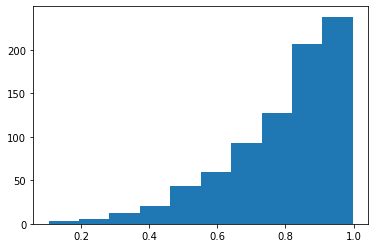

In [887]:
plt.hist(df_ols_all.R2)

In [888]:
df_ols_sub = df_ols_all[df_ols_all.R2 > 0.7].copy()

In [889]:
df_ols_sub

,Intercept,avg_price,cnvrsn_rate,gv,rep_oos,rvw_cnt,sale_rank,star12_cnt,star12_ratio,p_Intercept,p_avg_price,p_cnvrsn_rate,p_gv,p_rep_oos,p_rvw_cnt,p_sale_rank,p_star12_cnt,p_star12_ratio,R2,model
B00WNF65Q8,-3523.0391,11.9263,132300.0,1.6963,853.9225,108.8131,0.0006,313.8001,313.8001,0.0,0.016,0.0,0.0,0.732,0.349,1.0,0.377,0.377,0.922,<statsmodels.regression.linear_model.OLS objec...
B074Q46PD1,-19490.0,513.539,68030.0,2.2422,1596.7018,-138.8935,0.0441,240.6059,-916.2039,0.0,0.0,0.0,0.0,0.203,0.116,0.654,0.734,0.714,0.917,<statsmodels.regression.linear_model.OLS objec...
B074Q5KRSQ,918.2361,-12.1902,18700.0,2.1002,-1240.838,62.8962,-0.006,-521.1961,859.0072,0.197,0.203,0.0,0.0,0.001,0.394,0.809,0.255,0.196,0.855,<statsmodels.regression.linear_model.OLS objec...
B06WVPD4CS,-18450.0,47.6636,656800.0,2.9802,-1648.9261,256.8892,-3.609,631.8326,-2534.5354,0.0,0.0,0.0,0.0,0.657,0.168,0.001,0.68,0.343,0.956,<statsmodels.regression.linear_model.OLS objec...
B06WVXXDBP,-8362.7912,16.6358,203000.0,4.4066,4414.0143,-237.7574,0.0005,2175.4147,-1415.6934,0.0,0.0,0.0,0.0,0.0,0.208,0.999,0.275,0.579,0.972,<statsmodels.regression.linear_model.OLS objec...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B00PZ03VE2,3310.3099,-24.2353,174.5935,1.5599,-105.7712,299.0263,-0.0516,-157.293,-157.293,0.033,0.038,0.878,0.0,0.388,0.031,0.872,0.193,0.193,0.937,<statsmodels.regression.linear_model.OLS objec...
B078MQ2D8B,1015.8181,-4.0608,399.0475,1.037,-0.0,-3.4877,-0.1395,0.0,0.0,0.329,0.484,0.836,0.0,0.817,0.986,0.246,NaN,NaN,0.703,<statsmodels.regression.linear_model.OLS objec...
B077H7FJLG,33.7968,-0.6489,623.0266,4.7953,-64.0686,-30.971,0.1357,-27.1892,-27.1892,0.674,0.082,0.001,0.0,0.324,0.433,0.204,0.662,0.662,0.705,<statsmodels.regression.linear_model.OLS objec...
B07T9K9N71,20.9218,-1.3492,21640.0,2.7857,-15.5322,-44.9536,0.1054,70.1928,70.1928,0.971,0.451,0.0,0.0,0.912,0.783,0.443,0.817,0.817,0.736,<statsmodels.regression.linear_model.OLS objec...


In [913]:
df_ols_sub[['Intercept', 'avg_price', 'cnvrsn_rate', 'gv', 'rep_oos', 'rvw_cnt',
       'sale_rank', 'star12_cnt', 'star12_ratio','R2']]

,Intercept,avg_price,cnvrsn_rate,gv,rep_oos,rvw_cnt,sale_rank,star12_cnt,star12_ratio,R2
B00WNF65Q8,-3523.0391,11.9263,132300.0,1.6963,853.9225,108.8131,0.0006,313.8001,313.8001,0.922
B074Q46PD1,-19490.0,513.539,68030.0,2.2422,1596.7018,-138.8935,0.0441,240.6059,-916.2039,0.917
B074Q5KRSQ,918.2361,-12.1902,18700.0,2.1002,-1240.838,62.8962,-0.006,-521.1961,859.0072,0.855
B06WVPD4CS,-18450.0,47.6636,656800.0,2.9802,-1648.9261,256.8892,-3.609,631.8326,-2534.5354,0.956
B06WVXXDBP,-8362.7912,16.6358,203000.0,4.4066,4414.0143,-237.7574,0.0005,2175.4147,-1415.6934,0.972
...,...,...,...,...,...,...,...,...,...,...
B00PZ03VE2,3310.3099,-24.2353,174.5935,1.5599,-105.7712,299.0263,-0.0516,-157.293,-157.293,0.937
B078MQ2D8B,1015.8181,-4.0608,399.0475,1.037,-0.0,-3.4877,-0.1395,0.0,0.0,0.703
B077H7FJLG,33.7968,-0.6489,623.0266,4.7953,-64.0686,-30.971,0.1357,-27.1892,-27.1892,0.705
B07T9K9N71,20.9218,-1.3492,21640.0,2.7857,-15.5322,-44.9536,0.1054,70.1928,70.1928,0.736


In [912]:
df_ols_sub.columns

Index(['Intercept', 'avg_price', 'cnvrsn_rate', 'gv', 'rep_oos', 'rvw_cnt',
       'sale_rank', 'star12_cnt', 'star12_ratio', 'p_Intercept', 'p_avg_price',
       'p_cnvrsn_rate', 'p_gv', 'p_rep_oos', 'p_rvw_cnt', 'p_sale_rank',
       'p_star12_cnt', 'p_star12_ratio', 'R2', 'model'],
      dtype='object')

In [911]:
601/821

0.7320341047503045

In [890]:
df_ols_sub.to_excel('./results/df_ols_sub.xlsx')

### number of predictors having p value < 0.001

In [891]:
pVal = df_ols_sub[['p_'+x for x in predictors]]<0.001

In [892]:
pVal['n_count'] = [sum(row) for _,row in pVal.iterrows()]

In [893]:
pVal

,p_Intercept,p_avg_price,p_cnvrsn_rate,p_gv,p_rep_oos,p_rvw_cnt,p_sale_rank,p_star12_cnt,p_star12_ratio,n_count
B00WNF65Q8,True,False,True,True,False,False,False,False,False,3
B074Q46PD1,True,True,True,True,False,False,False,False,False,4
B074Q5KRSQ,False,False,True,True,False,False,False,False,False,2
B06WVPD4CS,True,True,True,True,False,False,False,False,False,4
B06WVXXDBP,True,True,True,True,True,False,False,False,False,5
...,...,...,...,...,...,...,...,...,...,...
B00PZ03VE2,False,False,False,True,False,False,False,False,False,1
B078MQ2D8B,False,False,False,True,False,False,False,False,False,1
B077H7FJLG,False,False,False,True,False,False,False,False,False,1
B07T9K9N71,False,False,True,True,False,False,False,False,False,2


In [914]:
pVal.n_count.describe().round()

count    601.0
mean       3.0
std        1.0
min        1.0
25%        2.0
50%        3.0
75%        4.0
max        7.0
Name: n_count, dtype: float64

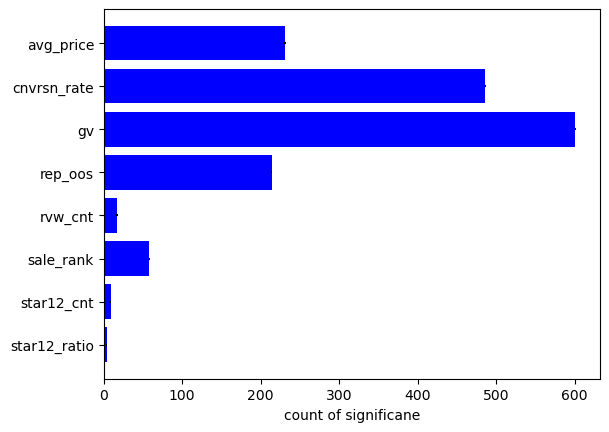

In [930]:
plt.rcdefaults()
fig, ax = plt.subplots()

# Example data
predtrs = ('avg_price',
 'cnvrsn_rate',
 'gv',
 'rep_oos',
 'rvw_cnt',
 'sale_rank',
 'star12_cnt',
 'star12_ratio')
y_pos = np.arange(len(predtrs))
performance = pVal.sum()[1:-1]
error = np.random.rand(len(predtrs))

ax.barh(y_pos, performance, color='b', xerr=error, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(predtrs)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('count of significane')
#ax.set_title('How fast do you want to go today?')

plt.show()

### Scatter plot of maximum number of predictors

In [895]:
pVal[pVal.n_count>6]

,p_Intercept,p_avg_price,p_cnvrsn_rate,p_gv,p_rep_oos,p_rvw_cnt,p_sale_rank,p_star12_cnt,p_star12_ratio,n_count
B07DNLT2VG,True,True,True,True,False,False,True,True,True,7


In [896]:
df_ols_all.loc[pVal[pVal.n_count>6].index]

,Intercept,avg_price,cnvrsn_rate,gv,rep_oos,rvw_cnt,sale_rank,star12_cnt,star12_ratio,p_Intercept,p_avg_price,p_cnvrsn_rate,p_gv,p_rep_oos,p_rvw_cnt,p_sale_rank,p_star12_cnt,p_star12_ratio,R2,model
B07DNLT2VG,-7993.0273,48.3049,84830.0,3.1333,264.5896,-91.8747,1.854,4011.0577,-5058.7746,0.0,0.0,0.0,0.0,0.489,0.276,0.0,0.0,0.0,0.938,<statsmodels.regression.linear_model.OLS objec...


In [897]:
result = df_ols_all.loc[pVal[pVal.n_count>6].index].model.values[0].fit()

In [898]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                ord_rev   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     223.7
Date:                Tue, 12 Jul 2022   Prob (F-statistic):           1.52e-67
Time:                        16:36:11   Log-Likelihood:                -1035.1
No. Observations:                 127   AIC:                             2088.
Df Residuals:                     118   BIC:                             2114.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept    -7993.0273    727.791    -10.983      0.000   -9434.251   -6551.803
avg_price       48.3049      9.597      5.033      0.000      29.300      67.309
cnvrsn_rate   8.483e+04   6564.539     12.922      0.000    7.18e+04    9.78e+04
gv               3.1333      0.116     27.092      0.000       2.904       3.362
rep_oos        264.5896    381.632      0.693      0.489    -491.145    1020.324
rvw_cnt        -91.8747     83.903     -1.095      0.276    -258.026      74.276
sale_rank        1.8540      0.296      6.262      0.000       1.268       2.440
star12_cnt    4011.0577    924.690      4.338      0.000    2179.920    5842.196
star12_ratio -5058.7746   1303.445     -3.881      0.000   -7639.950   -2477.599
==============================================================================
Omnibus:                       20.863   Durbin-Watson:                   1.437
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               94.761
Skew:                           0.297   Prob(JB):                     2.65e-21
Kurtosis:                       7.190   Cond. No.                     1.22e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.22e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1


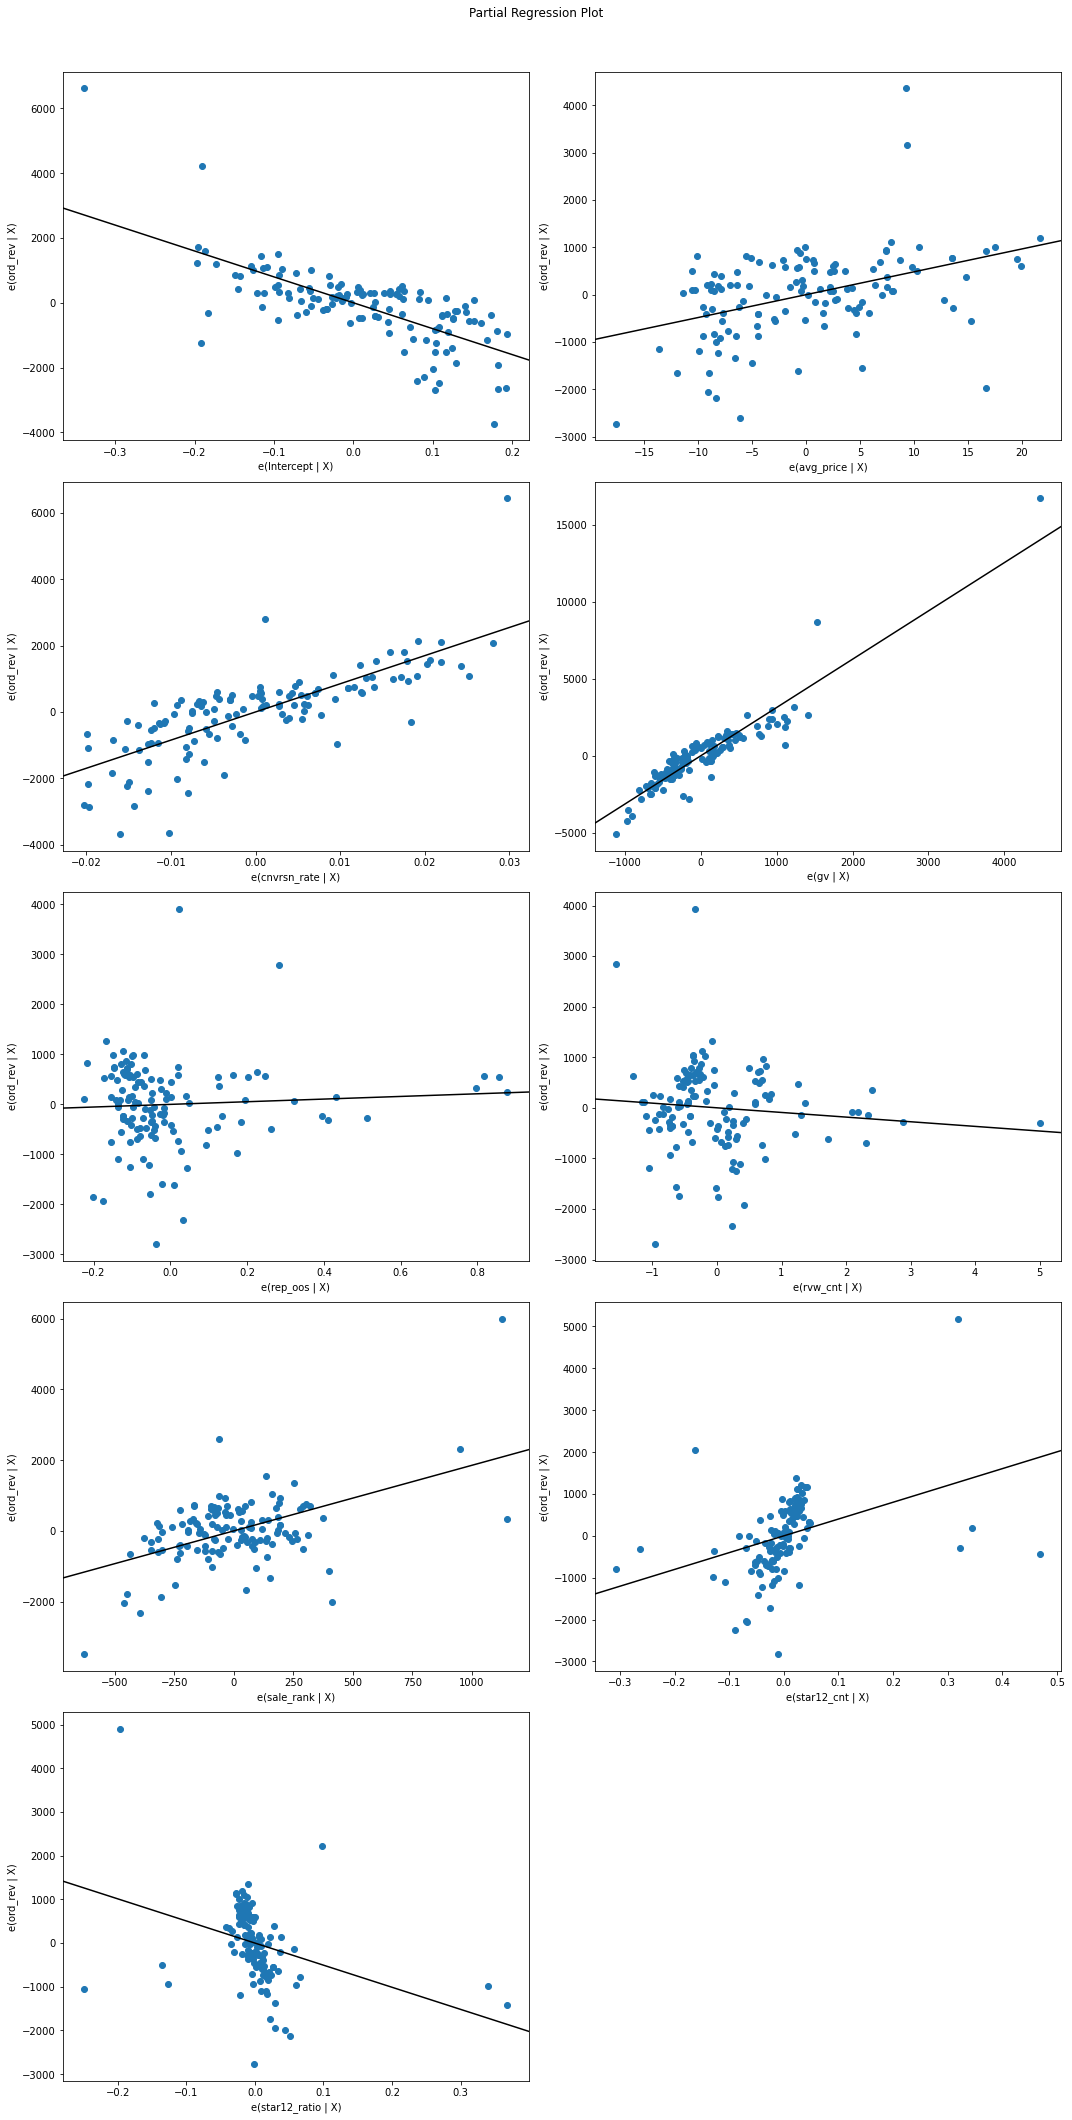

In [899]:
fig = plt.figure(figsize=(15, 30))
plot_partregress_grid(result, fig=fig)
plt.show()

### Conjugating meta information

In [900]:
df_meta = df_set[['asin', 'prdct_title','zinus_sku', 'collection', 'profile','size']].drop_duplicates().set_index('asin')
df_meta.head(10)

,prdct_title,zinus_sku,collection,profile,size
asin,,,,,
B00WNF65Q8,Zinus Arnav Modern Studio 10 Inch Platform 200...,AZ-ASMP-10T,ASMP,10 Inch,Twin
B075GY6KHB,"Zinus Deluxe wood with headboard Platform Bed,...",OLB-PWPBBHO-12Q,OLB PWPBBHO,5.75 Inch,Queen
B074Q46PD1,Zinus OLB-PS-1713 2 Step Comfort Pet Stairs/Pe...,OLB-PS-1713,OLB PS,None,None
B074Q5KRSQ,Zinus 4 Step Comfort Pet Stairs/Pet Ramp/Pet L...,OLB-PS-2525,OLB PS,None,None
B06WVPD4CS,Zinus Marissa 12 Inch Deluxe Wood Platform Bed...,OLB-PWPBBE-12Q,OLB PWPBBE,5.75 Inch,Queen
B06WVXXDBP,Zinus Marissa 12 Inch Deluxe Wood Platform Bed...,OLB-PWPBBE-12F,OLB PWPBBE,5.75 Inch,Full
B06X9FSGJ5,Zinus Marissa 12 Inch Deluxe Wood Platform Bed...,OLB-PWPBBE-12K,OLB PWPBBE,5.75 Inch,King
B0716FHHC3,Zinus Vivek 12 Inch Deluxe Wood Platform Bed w...,OLB-PWPBBHE-12K,OLB PWPBBHE,12 inch,King
B07256KYH4,Zinus Vivek 12 Inch Deluxe Wood Platform Bed w...,OLB-PWPBBHE-12F,OLB PWPBBHE,12 inch,Full


In [901]:
meta_pVal = df_meta.join(pVal).sort_values(by=['collection','zinus_sku','profile','size'])
meta_pVal

,prdct_title,zinus_sku,collection,profile,size,p_Intercept,p_avg_price,p_cnvrsn_rate,p_gv,p_rep_oos,p_rvw_cnt,p_sale_rank,p_star12_cnt,p_star12_ratio,n_count
asin,,,,,,,,,,,,,,,
B00WNF67DO,Zinus Arnav Modern Studio 10 Inch Platform 200...,AZ-ASMP-10F,ASMP,10 Inch,Full,False,False,True,True,False,False,False,False,False,2.0
B00WNF6HL6,Zinus Arnav Modern Studio 10 Inch Platform 200...,AZ-ASMP-10K,ASMP,10 Inch,King,True,True,True,True,False,False,False,False,False,4.0
B00WNF6GAI,Zinus Arnav Modern Studio 10 Inch Platform 200...,AZ-ASMP-10Q,ASMP,10 Inch,Queen,True,True,True,True,True,False,False,False,False,5.0
B00WNF65Q8,Zinus Arnav Modern Studio 10 Inch Platform 200...,AZ-ASMP-10T,ASMP,10 Inch,Twin,True,False,True,True,False,False,False,False,False,3.0
B01AB688F6,Zinus Mia Modern Studio 14 Inch Platform 1500 ...,AZ-ASMP-15F,ASMP,14 Inch,Full,True,False,True,True,False,False,False,False,False,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B00VKXV7UI,Zinus Gerard Faux Leather Upholstered Platform...,WSPB-F,WSPB,None,Full,True,False,True,True,True,False,False,False,False,4.0
B00R6OX5IM,Zinus Gerard Faux Leather Upholstered Platform...,WSPB-K,WSPB,None,King,True,False,True,True,False,False,False,False,False,3.0
B00NHWGGWE,Zinus Gerard Faux Leather Upholstered Platform...,WSPB-Q,WSPB,None,Queen,True,True,True,True,False,False,False,False,False,4.0


In [902]:
meta_pVal.to_excel('./results/meta_pVal.xlsx')

# Replacing NA & adding lagged features

* `avg_price` : ffill
* `sale_rank` : ffill
* `cnvrsn_rate` : ffill

* `gv` : 0
* `rep_oos` : 0
* `rvw_cnt` : 0
* `star12_cnt` : 0
* `star12_ratio` : 0

## date range and filling

In [903]:
# columns to be lagged and appended
metrics = ['sale_rank', 'avg_price','gv', 'cnvrsn_rate', 'rep_oos', 'rvw_cnt', 'star12_cnt', 'star12_ratio']

df_set2 = pd.DataFrame(columns=df_sub.columns)

for coll_asin in colls_asins:
    tmp_df = pd.DataFrame(index=dt_rg)
    tmp_df = tmp_df.join(df_sub[(df_sub.collection==coll_asin[0]) \
                   & (df_sub.asin==coll_asin[1])].set_index('year_week'))
    tmp_df.sort_values(by='year_week',inplace=True)
    
    collection = tmp_df.collection[0]
    asin = tmp_df.asin[0]
    prdct_title = tmp_df.prdct_title[0]
    zinus_sku = tmp_df.zinus_sku[0]
    profile = tmp_df.profile[0]
    size = tmp_df['size'][0]
    
    tmp_df = tmp_df.resample('W-Sun').mean()
    
    tmp_df[['collection','asin','prdct_title','zinus_sku','profile','size']] = \
            [collection,asin,prdct_title,zinus_sku,profile,size]
    
    tmp_df[['avg_price','sale_rank','cnvrsn_rate']] = \
            tmp_df[['avg_price','sale_rank','cnvrsn_rate']].ffill()
    tmp_df[['gv','rep_oos','rvw_cnt','star12_cnt','star12_ratio']] = \
            tmp_df[['gv','rep_oos','rvw_cnt','star12_cnt','star12_ratio']].fillna(0)
    
    # Ill conditioned quickly
    for metric in metrics:
        for k in range(4):
            metric_lag = tmp_df[metric].shift(k+1)
            tmp_df[metric+'_lag'+str(k+1)] = metric_lag
    tmp_df.dropna(inplace=True)
    
    tmp_df.reset_index(inplace=True)
    df_set2 = df_set2.append(tmp_df)

In [904]:
df_sub.shape

(104698, 17)

In [905]:
df_set2.shape

(67605, 49)

In [906]:
len(df_set2.asin.unique())

552

## Linear model

In [907]:
df_set2.columns

Index(['asin', 'prdct_title', 'ord_rev', 'ord_qty', 'sale_rank', 'avg_price',
       'gv', 'cnvrsn_rate', 'rep_oos', 'zinus_sku', 'collection', 'profile',
       'size', 'rvw_cnt', 'star12_cnt', 'star12_ratio', 'year_week',
       'sale_rank_lag1', 'sale_rank_lag2', 'sale_rank_lag3', 'sale_rank_lag4',
       'avg_price_lag1', 'avg_price_lag2', 'avg_price_lag3', 'avg_price_lag4',
       'gv_lag1', 'gv_lag2', 'gv_lag3', 'gv_lag4', 'cnvrsn_rate_lag1',
       'cnvrsn_rate_lag2', 'cnvrsn_rate_lag3', 'cnvrsn_rate_lag4',
       'rep_oos_lag1', 'rep_oos_lag2', 'rep_oos_lag3', 'rep_oos_lag4',
       'rvw_cnt_lag1', 'rvw_cnt_lag2', 'rvw_cnt_lag3', 'rvw_cnt_lag4',
       'star12_cnt_lag1', 'star12_cnt_lag2', 'star12_cnt_lag3',
       'star12_cnt_lag4', 'star12_ratio_lag1', 'star12_ratio_lag2',
       'star12_ratio_lag3', 'star12_ratio_lag4'],
      dtype='object')

In [908]:
p = list(set(df_set2.columns)-set(['ord_rev',\
                                  'ord_qty',\
                                  'asin',\
                                  'prdct_title',\
                                  'zinus_sku',\
                                  'collection',\
                                  'profile',\
                                  'size',\
                                 'year_week'\
                                  ]))
p.sort()

In [909]:
predictors = ['Intercept'] + p
predictors = predictors
predictors

['Intercept',
 'avg_price',
 'avg_price_lag1',
 'avg_price_lag2',
 'avg_price_lag3',
 'avg_price_lag4',
 'cnvrsn_rate',
 'cnvrsn_rate_lag1',
 'cnvrsn_rate_lag2',
 'cnvrsn_rate_lag3',
 'cnvrsn_rate_lag4',
 'gv',
 'gv_lag1',
 'gv_lag2',
 'gv_lag3',
 'gv_lag4',
 'rep_oos',
 'rep_oos_lag1',
 'rep_oos_lag2',
 'rep_oos_lag3',
 'rep_oos_lag4',
 'rvw_cnt',
 'rvw_cnt_lag1',
 'rvw_cnt_lag2',
 'rvw_cnt_lag3',
 'rvw_cnt_lag4',
 'sale_rank',
 'sale_rank_lag1',
 'sale_rank_lag2',
 'sale_rank_lag3',
 'sale_rank_lag4',
 'star12_cnt',
 'star12_cnt_lag1',
 'star12_cnt_lag2',
 'star12_cnt_lag3',
 'star12_cnt_lag4',
 'star12_ratio',
 'star12_ratio_lag1',
 'star12_ratio_lag2',
 'star12_ratio_lag3',
 'star12_ratio_lag4']

In [910]:
expr='ord_rev ~ '
for pred in predictors[1:]:
    expr = expr+pred+' + '
expr = expr[:-3]

expr

'ord_rev ~ avg_price + avg_price_lag1 + avg_price_lag2 + avg_price_lag3 + avg_price_lag4 + cnvrsn_rate + cnvrsn_rate_lag1 + cnvrsn_rate_lag2 + cnvrsn_rate_lag3 + cnvrsn_rate_lag4 + gv + gv_lag1 + gv_lag2 + gv_lag3 + gv_lag4 + rep_oos + rep_oos_lag1 + rep_oos_lag2 + rep_oos_lag3 + rep_oos_lag4 + rvw_cnt + rvw_cnt_lag1 + rvw_cnt_lag2 + rvw_cnt_lag3 + rvw_cnt_lag4 + sale_rank + sale_rank_lag1 + sale_rank_lag2 + sale_rank_lag3 + sale_rank_lag4 + star12_cnt + star12_cnt_lag1 + star12_cnt_lag2 + star12_cnt_lag3 + star12_cnt_lag4 + star12_ratio + star12_ratio_lag1 + star12_ratio_lag2 + star12_ratio_lag3 + star12_ratio_lag4'

**This does not give results using full predictors, due to ill-conditioned inverse**

In [931]:
ASINs = df_set2.asin.dropna().unique().tolist()

cols = predictors + ['p_'+x for x in predictors] + ['R2','model']
df_ols_all2 = pd.DataFrame(columns=cols,index=ASINs)

for asin in ASINs:
    tmp_df_set2 = df_set2[df_set2.asin==asin].copy()
    
        # should be kept 'int64'
    # df['x'] = pd.to_numeric(df['x'], downcast='float', errors='raise').astype('Int64')
    tmp_df_set2 = tmp_df_set2.astype(
        {'ord_qty':'float64',\
         'sale_rank':'float64',\
         'sale_rank_lag1':'float64',\
         'sale_rank_lag2':'float64',\
         'sale_rank_lag3':'float64',\
         'sale_rank_lag4':'float64',\
         
         'gv':'float64',\
         'gv_lag1':'float64',\
         'gv_lag2':'float64',\
         'gv_lag3':'float64',\
         'gv_lag4':'float64',\
         
         
         'rvw_cnt':'float64',\
         'rvw_cnt_lag1':'float64',\
         'rvw_cnt_lag2':'float64',\
         'rvw_cnt_lag3':'float64',\
         'rvw_cnt_lag4':'float64',\
         
         'star12_cnt':'float64',\
         'star12_cnt_lag1':'float64',\
         'star12_cnt_lag2':'float64',\
         'star12_cnt_lag3':'float64',\
         'star12_cnt_lag4':'float64'
         
        })
    
    model = sm.OLS.from_formula(expr, data=tmp_df_set2)
    result = model.fit()
    tmp_ols = result.summary().tables[1].data

    coeffs = list()
    p_coeffs = list()
    for k in range(len(predictors)): # Without Intercept
        coeffs.append(float(tmp_ols[k+1][1])) # Coefficients
        p_coeffs.append(float(tmp_ols[k+1][4])) # P > |t|
    coeffs.extend(p_coeffs)
    
    r2 = [float(result.summary().tables[0].data[0][-1])] # R-squrared
    coeffs.extend(r2)
    coeffs.extend([model])
    df_ols_all2.loc[asin] = coeffs
    
    print(f"model rank : %d" %model.rank)
    #del tmp_df_set2, tmp_ols, result, coeffs, p_coeffs, r2

model rank : 36
model rank : 41
model rank : 41
model rank : 39
model rank : 41
model rank : 36
model rank : 41
model rank : 36
model rank : 41
model rank : 31
model rank : 36
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 36
model rank : 31
model rank : 31
model rank : 26
model rank : 36
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 36
model rank : 41
model rank : 36
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 36
model rank : 41
model rank : 41
model rank : 36
model rank : 31
model rank : 36
model rank : 36
model rank : 41
model rank : 36
model rank : 36
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 41
model rank : 36
model rank : 36
model rank : 36
model rank : 41
model rank : 36
model rank : 41
model rank : 35
model rank : 36
model ra

model rank : 36
model rank : 31
model rank : 36
model rank : 41
model rank : 36
model rank : 31
model rank : 41
model rank : 31
model rank : 31
model rank : 41
model rank : 36
model rank : 31
model rank : 33
model rank : 31
model rank : 36
model rank : 36
model rank : 31
model rank : 36
model rank : 36
model rank : 36
model rank : 36
model rank : 36
model rank : 31
model rank : 31
model rank : 26
model rank : 41
model rank : 31
model rank : 41
model rank : 41
model rank : 41
model rank : 35
model rank : 31
model rank : 26
model rank : 36
model rank : 36
model rank : 36
model rank : 21


## Performance evaluation

### R2 

In [932]:
df_ols_all2.sort_values(by='R2',ascending=False)

,Intercept,avg_price,avg_price_lag1,avg_price_lag2,avg_price_lag3,avg_price_lag4,cnvrsn_rate,cnvrsn_rate_lag1,cnvrsn_rate_lag2,cnvrsn_rate_lag3,...,p_star12_cnt_lag2,p_star12_cnt_lag3,p_star12_cnt_lag4,p_star12_ratio,p_star12_ratio_lag1,p_star12_ratio_lag2,p_star12_ratio_lag3,p_star12_ratio_lag4,R2,model
B075FG9J8S,-22170.0,26.2333,15.2599,-0.6465,22.6534,-7.3127,934300.0,-8570.5841,30120.0,25580.0,...,0.032,0.076,0.728,0.91,0.173,0.051,0.084,0.691,0.998,<statsmodels.regression.linear_model.OLS objec...
B071Z269FW,-38890.0,97.2385,32.8232,-18.3406,-0.4562,0.6562,413500.0,-3725.1665,-6467.0097,15580.0,...,0.741,0.763,0.0,0.427,0.82,0.881,0.593,0.0,0.996,<statsmodels.regression.linear_model.OLS objec...
B00Q7EPSHI,-1818000.0,3115.5015,70.4207,-519.8896,-434.7702,993.4683,25120000.0,60780.0,-4596000.0,1442000.0,...,0.316,0.864,0.693,0.556,0.741,0.912,0.016,0.061,0.995,<statsmodels.regression.linear_model.OLS objec...
B075GW5ZM6,-11530.0,32.5427,-10.943,0.9572,-7.1558,5.6002,322800.0,-48550.0,-29650.0,11890.0,...,0.91,0.1,0.348,0.088,0.835,0.556,0.059,0.186,0.993,<statsmodels.regression.linear_model.OLS objec...
B075GVDCXD,-6970.712,16.324,0.9931,-1.7964,0.3647,4.3771,414300.0,-23310.0,-9418.3885,-31600.0,...,0.788,0.459,0.807,0.495,0.189,0.637,0.843,0.264,0.992,<statsmodels.regression.linear_model.OLS objec...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B06WW43GHL,122.1109,17.4792,-1.7683,-5.7411,18.0994,-25.8732,59580.0,-23150.0,-15760.0,3497.2464,...,0.523,0.839,0.698,0.575,0.887,0.523,0.839,0.698,0.432,<statsmodels.regression.linear_model.OLS objec...
B0077U8YW2,-7173.1469,5.9839,25.6865,21.4595,-16.9782,18.119,14770.0,8649.8435,-4504.4995,4946.8354,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.39,<statsmodels.regression.linear_model.OLS objec...
B073HFL96Z,-54.0337,5.8548,-0.6608,-0.7162,-6.9746,8.6311,1717.6156,-131.5534,274.1812,500.3415,...,0.561,0.873,0.956,0.824,0.73,0.561,0.873,0.956,0.384,<statsmodels.regression.linear_model.OLS objec...
B01HIR5H9Q,3957.8456,8.4968,-14.5698,3.0205,-14.2684,19.8398,-550.3451,652.2119,4257.363,-1870.3481,...,0.814,0.976,0.811,0.184,0.161,0.814,0.976,0.811,0.342,<statsmodels.regression.linear_model.OLS objec...


(array([  2.,   3.,   5.,   6.,  19.,  39.,  53.,  73., 154., 198.]),
 array([0.305, 0.37429999999999997, 0.4436, 0.5129, 0.5822, 0.6515, 0.7208,
        0.7901, 0.8593999999999999, 0.9287000000000001, 0.998],
       dtype=object),
 <BarContainer object of 10 artists>)

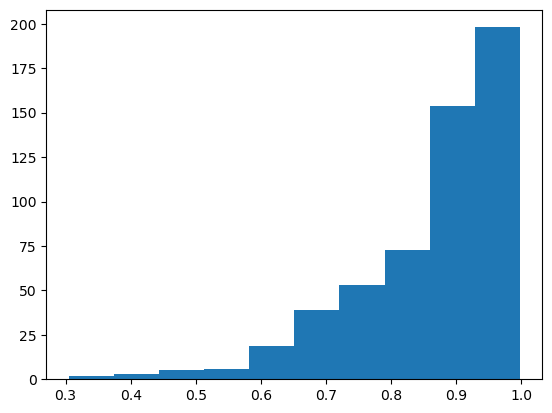

In [933]:
plt.hist(df_ols_all2.R2)

In [934]:
df_ols_sub2 = df_ols_all2[df_ols_all2.R2 > 0.7].copy()

In [935]:
df_ols_sub2

,Intercept,avg_price,avg_price_lag1,avg_price_lag2,avg_price_lag3,avg_price_lag4,cnvrsn_rate,cnvrsn_rate_lag1,cnvrsn_rate_lag2,cnvrsn_rate_lag3,...,p_star12_cnt_lag2,p_star12_cnt_lag3,p_star12_cnt_lag4,p_star12_ratio,p_star12_ratio_lag1,p_star12_ratio_lag2,p_star12_ratio_lag3,p_star12_ratio_lag4,R2,model
B00WNF65Q8,-1512.9918,13.4639,-1.0635,-10.2125,-1.451,11.1634,122700.0,9460.241,-679.3107,-3432.8071,...,0.347,0.034,0.568,0.164,0.184,0.347,0.034,0.568,0.941,<statsmodels.regression.linear_model.OLS objec...
B075GY6KHB,14520.0,-51.3615,16.1356,32.1696,3.1947,-51.4982,69990.0,-2407.9988,-17800.0,-13290.0,...,0.53,0.657,0.988,0.848,0.523,0.645,0.919,0.603,0.84,<statsmodels.regression.linear_model.OLS objec...
B06WVPD4CS,-18810.0,58.9244,5.2435,-3.2618,-7.5673,1.7463,672900.0,32250.0,-68860.0,66040.0,...,0.132,0.049,0.003,0.097,0.787,0.214,0.02,0.0,0.978,<statsmodels.regression.linear_model.OLS objec...
B06WVXXDBP,-7844.792,6.6565,7.9873,-3.2722,9.1357,-4.7267,192300.0,-22550.0,29630.0,13310.0,...,0.57,0.405,0.126,0.221,0.684,0.529,0.405,0.126,0.985,<statsmodels.regression.linear_model.OLS objec...
B06X9FSGJ5,-17370.0,22.0173,-1.9174,-32.0437,40.4652,5.8306,299800.0,-28910.0,3253.134,125500.0,...,0.839,0.954,0.814,0.249,0.308,0.608,0.563,0.98,0.974,<statsmodels.regression.linear_model.OLS objec...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B06WWCCYQV,374.0163,-0.8206,7.585,-9.0187,6.5539,-6.948,2344.2126,3106.3387,1931.9447,-864.2768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.857,<statsmodels.regression.linear_model.OLS objec...
B079P6NBXZ,-62.9771,-8.7774,3.1665,3.5446,-2.1704,5.4842,2.042,-58.388,0.3512,-46.3181,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.864,<statsmodels.regression.linear_model.OLS objec...
B07KK2BZB9,-498.3056,-7.8966,-6.4885,0.0377,14.5227,1.0211,1913.7433,3566.908,-2524.3382,-5277.9025,...,0.078,0.029,0.342,0.437,0.994,0.078,0.029,0.342,0.92,<statsmodels.regression.linear_model.OLS objec...
B00PZ03VE2,456.7223,-33.2309,23.8625,33.5192,26.3701,-51.465,1113.2184,-561.345,497.6978,765.3098,...,0.183,0.514,0.349,0.555,0.296,0.183,0.514,0.349,0.971,<statsmodels.regression.linear_model.OLS objec...


In [952]:
df_ols_sub2[['Intercept', 'avg_price', 'cnvrsn_rate', 'gv', 'rep_oos', 'rvw_cnt',
       'sale_rank', 'star12_cnt', 'star12_ratio','R2']]

,Intercept,avg_price,cnvrsn_rate,gv,rep_oos,rvw_cnt,sale_rank,star12_cnt,star12_ratio,R2
B00WNF65Q8,-1512.9918,13.4639,122700.0,1.6603,-3784.613,51.8223,2.5372,588.9905,588.9905,0.941
B075GY6KHB,14520.0,-51.3615,69990.0,1.9675,-2775.1728,-548.6918,-1.8167,-2039.7926,1554.8118,0.84
B06WVPD4CS,-18810.0,58.9244,672900.0,2.9817,-5555.2766,-43.2312,-2.7123,1741.8586,-4340.4628,0.978
B06WVXXDBP,-7844.792,6.6565,192300.0,4.6345,3390.8902,-60.5673,0.0427,5671.4467,-3487.2504,0.985
B06X9FSGJ5,-17370.0,22.0173,299800.0,3.8322,-6494.7728,-2.5469,-0.4771,-1636.8615,1936.7505,0.974
...,...,...,...,...,...,...,...,...,...,...
B06WWCCYQV,374.0163,-0.8206,2344.2126,1.3053,-5585.5988,-85.8578,-0.0829,0.0,0.0,0.857
B079P6NBXZ,-62.9771,-8.7774,2.042,0.7762,-0.0,-0.9697,0.0642,0.0,0.0,0.864
B07KK2BZB9,-498.3056,-7.8966,1913.7433,1.6314,-203500.0,-449.7318,-0.116,1010.9308,505.4654,0.92
B00PZ03VE2,456.7223,-33.2309,1113.2184,1.5643,-164.8497,52.744,-0.9333,99.5131,99.5131,0.971


In [950]:
489/552

0.8858695652173914

In [936]:
df_ols_sub2.to_excel('./results/df_ols_sub2.xlsx')

### number of predictors having p value < 0.001

In [937]:
pVal2 = df_ols_sub2[['p_'+x for x in predictors]]<0.001

In [938]:
pVal2['n_count'] = [sum(row) for _,row in pVal2.iterrows()]

In [939]:
pVal2

,p_Intercept,p_avg_price,p_avg_price_lag1,p_avg_price_lag2,p_avg_price_lag3,p_avg_price_lag4,p_cnvrsn_rate,p_cnvrsn_rate_lag1,p_cnvrsn_rate_lag2,p_cnvrsn_rate_lag3,...,p_star12_cnt_lag1,p_star12_cnt_lag2,p_star12_cnt_lag3,p_star12_cnt_lag4,p_star12_ratio,p_star12_ratio_lag1,p_star12_ratio_lag2,p_star12_ratio_lag3,p_star12_ratio_lag4,n_count
B00WNF65Q8,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,2
B075GY6KHB,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,2
B06WVPD4CS,True,True,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,5
B06WVXXDBP,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,3
B06X9FSGJ5,True,False,False,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B06WWCCYQV,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
B079P6NBXZ,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
B07KK2BZB9,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1
B00PZ03VE2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2


In [953]:
pVal2[['p_avg_price', 'p_cnvrsn_rate', 'p_gv', 'p_rep_oos', 'p_rvw_cnt',
       'p_sale_rank', 'p_star12_cnt', 'p_star12_ratio','n_count']]

,p_avg_price,p_cnvrsn_rate,p_gv,p_rep_oos,p_rvw_cnt,p_sale_rank,p_star12_cnt,p_star12_ratio,n_count
B00WNF65Q8,False,True,True,False,False,False,False,False,2
B075GY6KHB,False,True,True,False,False,False,False,False,2
B06WVPD4CS,True,True,True,False,False,False,False,False,5
B06WVXXDBP,False,True,True,False,False,False,False,False,3
B06X9FSGJ5,False,True,True,True,False,False,False,False,6
...,...,...,...,...,...,...,...,...,...
B06WWCCYQV,False,False,True,False,False,False,False,False,1
B079P6NBXZ,False,False,True,False,False,False,False,False,1
B07KK2BZB9,False,False,True,False,False,False,False,False,1
B00PZ03VE2,False,False,True,False,False,False,False,False,2


In [940]:
len(predictors)-1

40

In [954]:
pVal2.n_count.describe().round()

count    489.0
mean       3.0
std        2.0
min        1.0
25%        2.0
50%        3.0
75%        4.0
max       10.0
Name: n_count, dtype: float64

In [955]:
predictors

['Intercept',
 'avg_price',
 'avg_price_lag1',
 'avg_price_lag2',
 'avg_price_lag3',
 'avg_price_lag4',
 'cnvrsn_rate',
 'cnvrsn_rate_lag1',
 'cnvrsn_rate_lag2',
 'cnvrsn_rate_lag3',
 'cnvrsn_rate_lag4',
 'gv',
 'gv_lag1',
 'gv_lag2',
 'gv_lag3',
 'gv_lag4',
 'rep_oos',
 'rep_oos_lag1',
 'rep_oos_lag2',
 'rep_oos_lag3',
 'rep_oos_lag4',
 'rvw_cnt',
 'rvw_cnt_lag1',
 'rvw_cnt_lag2',
 'rvw_cnt_lag3',
 'rvw_cnt_lag4',
 'sale_rank',
 'sale_rank_lag1',
 'sale_rank_lag2',
 'sale_rank_lag3',
 'sale_rank_lag4',
 'star12_cnt',
 'star12_cnt_lag1',
 'star12_cnt_lag2',
 'star12_cnt_lag3',
 'star12_cnt_lag4',
 'star12_ratio',
 'star12_ratio_lag1',
 'star12_ratio_lag2',
 'star12_ratio_lag3',
 'star12_ratio_lag4']

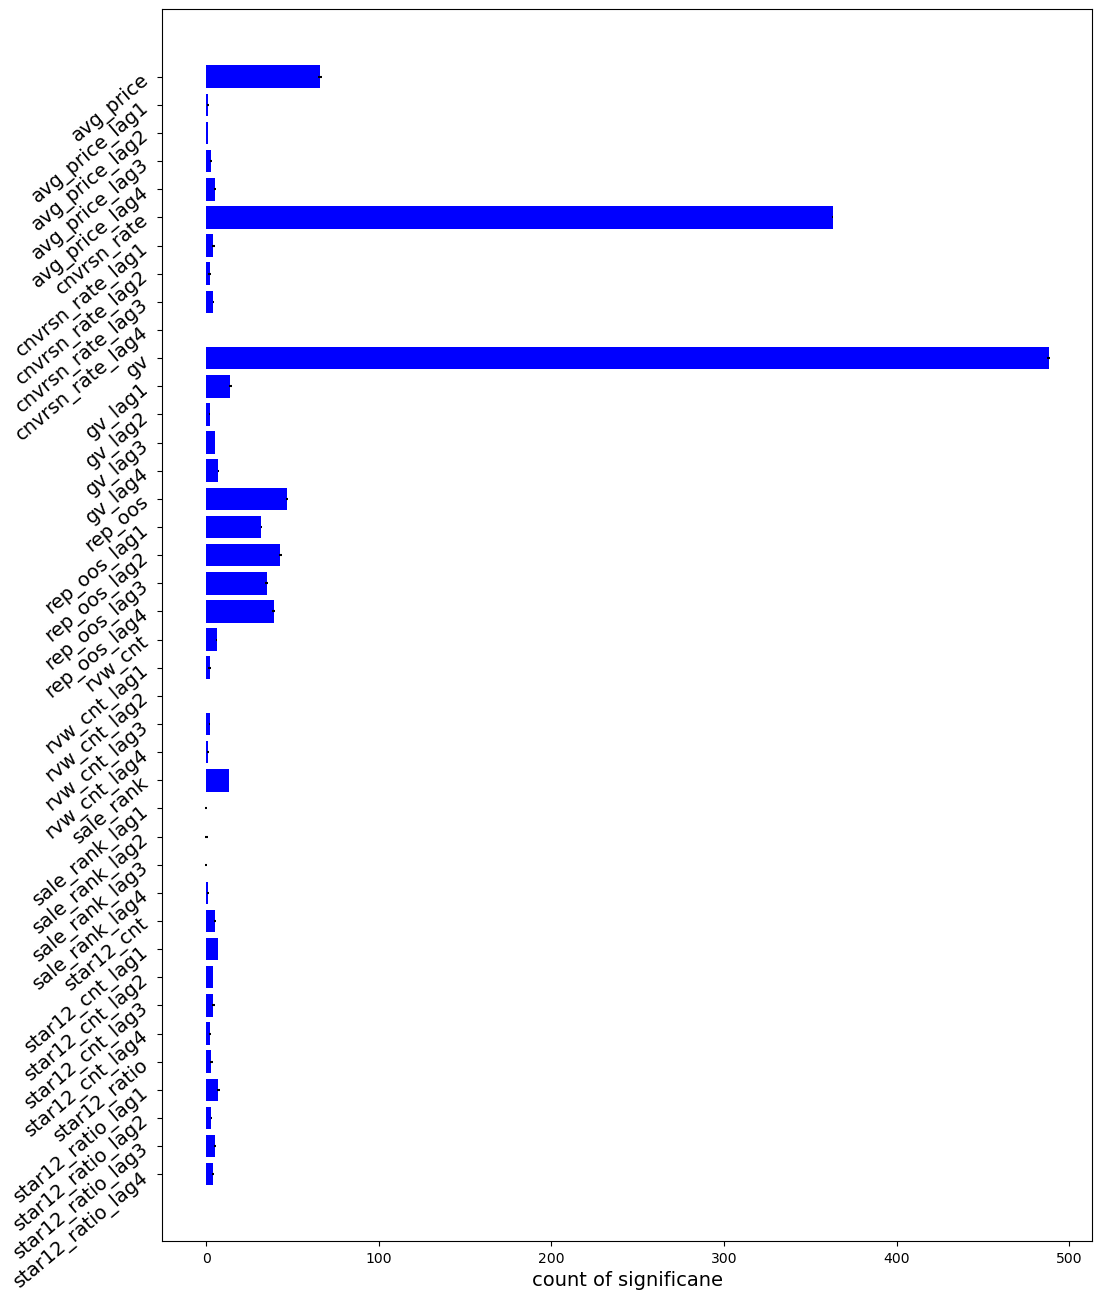

In [970]:
plt.rcdefaults()
fig, ax = plt.subplots(figsize=(12,16))

# Example data
predtrs = predictors[1:]
y_pos = np.arange(len(predtrs))
performance = pVal2.sum()[1:-1]
error = np.random.rand(len(predtrs))

ax.barh(y_pos, performance, color='b', xerr=error, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(predtrs,fontsize=14)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('count of significane',fontsize=14)
plt.yticks(rotation=40)
plt.show()

### Scatter plot of maximum number of predictors

In [942]:
pVal2[pVal2.n_count>9]

,p_Intercept,p_avg_price,p_avg_price_lag1,p_avg_price_lag2,p_avg_price_lag3,p_avg_price_lag4,p_cnvrsn_rate,p_cnvrsn_rate_lag1,p_cnvrsn_rate_lag2,p_cnvrsn_rate_lag3,...,p_star12_cnt_lag1,p_star12_cnt_lag2,p_star12_cnt_lag3,p_star12_cnt_lag4,p_star12_ratio,p_star12_ratio_lag1,p_star12_ratio_lag2,p_star12_ratio_lag3,p_star12_ratio_lag4,n_count
B071ZZWZTW,True,False,True,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,10


In [943]:
df_ols_all2.loc[pVal2[pVal2.n_count>9].index]

,Intercept,avg_price,avg_price_lag1,avg_price_lag2,avg_price_lag3,avg_price_lag4,cnvrsn_rate,cnvrsn_rate_lag1,cnvrsn_rate_lag2,cnvrsn_rate_lag3,...,p_star12_cnt_lag2,p_star12_cnt_lag3,p_star12_cnt_lag4,p_star12_ratio,p_star12_ratio_lag1,p_star12_ratio_lag2,p_star12_ratio_lag3,p_star12_ratio_lag4,R2,model
B071ZZWZTW,-52810.0,-0.3465,75.0178,-28.053,26.5794,15.5978,865100.0,216400.0,-13320.0,-103500.0,...,0.445,0.168,0.122,0.755,0.529,0.349,0.051,0.317,0.959,<statsmodels.regression.linear_model.OLS objec...


In [944]:
result = df_ols_all2.loc[pVal2[pVal2.n_count>9].index].model.values[0].fit()

In [945]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                ord_rev   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.943
Method:                 Least Squares   F-statistic:                     58.68
Date:                Tue, 12 Jul 2022   Prob (F-statistic):           3.84e-47
Time:                        17:06:29   Log-Likelihood:                -1231.0
No. Observations:                 123   AIC:                             2534.
Df Residuals:                      87   BIC:                             2635.
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5.281e+04   6613.044     -7.986      0.000    -6.6e+04   -3.97e+04
avg_price            -0.3465     19.684     -0.018      0.986     -39.471      38.779
avg_price_lag1       75.0178     20.171      3.719      0.000      34.926     115.110
avg_price_lag2      -28.0530     25.183     -1.114      0.268     -78.108      22.002
avg_price_lag3       26.5794     23.656      1.124      0.264     -20.440      73.599
avg_price_lag4       15.5978     23.080      0.676      0.501     -30.277      61.473
cnvrsn_rate        8.651e+05   7.88e+04     10.972      0.000    7.08e+05    1.02e+06
cnvrsn_rate_lag1   2.164e+05   8.47e+04      2.556      0.012    4.81e+04    3.85e+05
cnvrsn_rate_lag2  -1.332e+04   8.87e+04     -0.150      0.881    -1.9e+05    1.63e+05
cnvrsn_rate_lag3  -1.035e+05   7.84e+04     -1.321      0.190   -2.59e+05    5.22e+04
cnvrsn_rate_lag4   1.658e+04   6.95e+04      0.239      0.812   -1.21e+05    1.55e+05
gv                    5.9880      0.238     25.151      0.000       5.515       6.461
gv_lag1               0.0938      0.236      0.398      0.692      -0.374       0.562
gv_lag2               0.0114      0.221      0.052      0.959      -0.427       0.450
gv_lag3               1.0371      0.220      4.719      0.000       0.600       1.474
gv_lag4              -0.2356      0.219     -1.076      0.285      -0.671       0.200
rep_oos            -4.78e-05   1.05e-05     -4.537      0.000   -6.87e-05   -2.69e-05
rep_oos_lag1       2.849e-06   6.32e-07      4.507      0.000    1.59e-06    4.11e-06
rep_oos_lag2       2.142e-06   4.71e-07      4.547      0.000    1.21e-06    3.08e-06
rep_oos_lag3       3.868e-06   8.51e-07      4.544      0.000    2.18e-06    5.56e-06
rep_oos_lag4      -7.714e-07   1.71e-07     -4.519      0.000   -1.11e-06   -4.32e-07
rvw_cnt             611.0472    648.207      0.943      0.348    -677.335    1899.430
rvw_cnt_lag1        651.3205    631.537      1.031      0.305    -603.927    1906.568
rvw_cnt_lag2        293.1548    629.689      0.466      0.643    -958.421    1544.730
rvw_cnt_lag3       -128.8021    572.605     -0.225      0.823   -1266.917    1009.312
rvw_cnt_lag4        435.9437    579.298      0.753      0.454    -715.473    1587.361
sale_rank            23.4015     17.080      1.370      0.174     -10.547      57.350
sale_rank_lag1       -3.6300     17.997     -0.202      0.841     -39.401      32.141
sale_rank_lag2       -2.8946     18.738     -0.154      0.878     -40.139      34.350
sale_rank_lag3       -4.6461     17.690     -0.263      0.793     -39.807      30.515
sale_rank_lag4        8.2759     16.455      0.503      0.616     -24.431      40.983
star12_cnt        -1815.3654   3340.922     -0.543      0.588   -8455.810    4825.079
star12_cnt_lag1     613.1167   3370.663      0.182      0.856   -6086.442

eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1
eval_env: 1


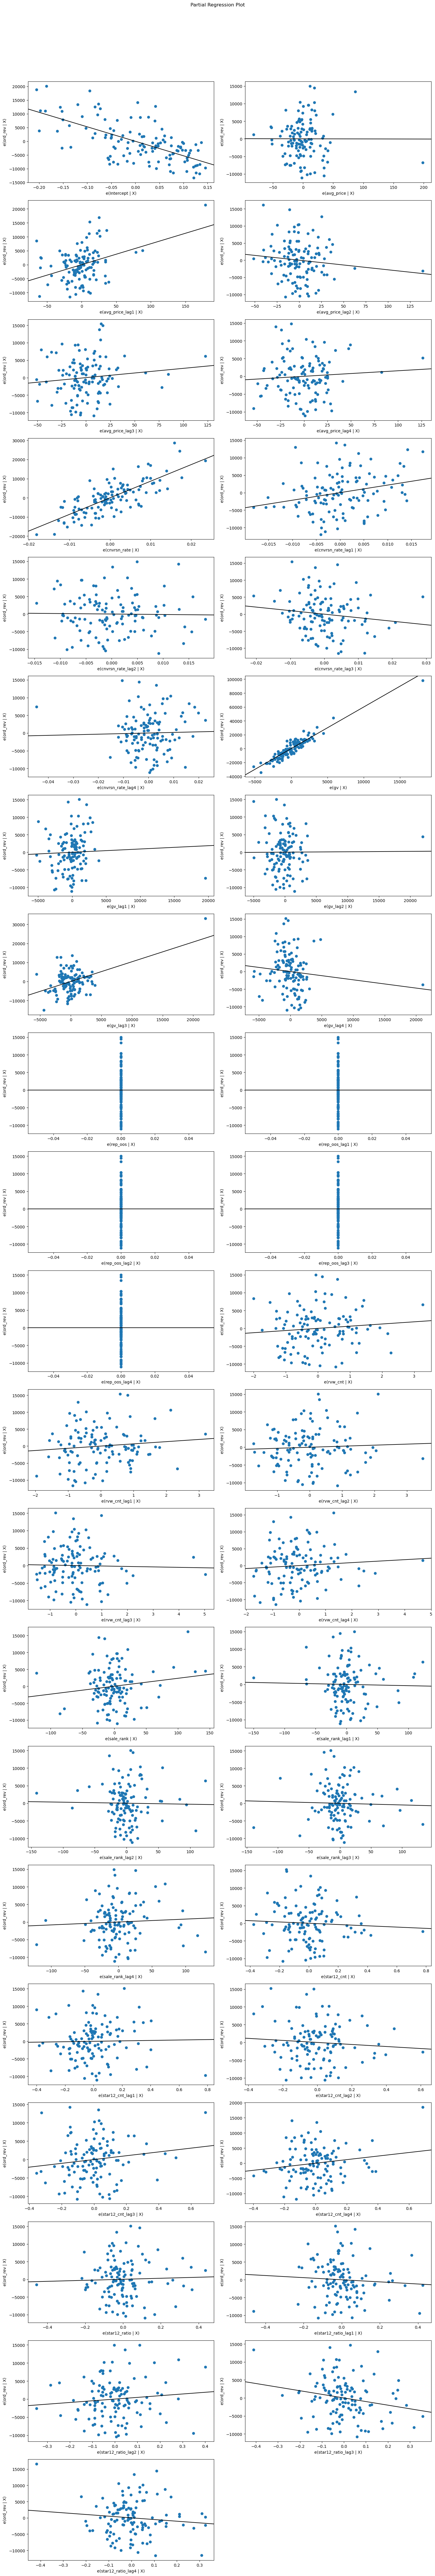

In [946]:
fig = plt.figure(figsize=(15, 90))
plot_partregress_grid(result, fig=fig)
plt.show()

### Conjugating meta information

In [947]:
df_meta2 = df_set2[['asin', 'prdct_title','zinus_sku', 'collection', 'profile','size']].drop_duplicates().set_index('asin')
df_meta2.head(10)

,prdct_title,zinus_sku,collection,profile,size
asin,,,,,
B00WNF65Q8,Zinus Arnav Modern Studio 10 Inch Platform 200...,AZ-ASMP-10T,ASMP,10 Inch,Twin
B075GY6KHB,"Zinus Deluxe wood with headboard Platform Bed,...",OLB-PWPBBHO-12Q,OLB PWPBBHO,5.75 Inch,Queen
B06WVPD4CS,Zinus Marissa 12 Inch Deluxe Wood Platform Bed...,OLB-PWPBBE-12Q,OLB PWPBBE,5.75 Inch,Queen
B06WVXXDBP,Zinus Marissa 12 Inch Deluxe Wood Platform Bed...,OLB-PWPBBE-12F,OLB PWPBBE,5.75 Inch,Full
B06X9FSGJ5,Zinus Marissa 12 Inch Deluxe Wood Platform Bed...,OLB-PWPBBE-12K,OLB PWPBBE,5.75 Inch,King
B0716FHHC3,Zinus Vivek 12 Inch Deluxe Wood Platform Bed w...,OLB-PWPBBHE-12K,OLB PWPBBHE,12 inch,King
B07256KYH4,Zinus Vivek 12 Inch Deluxe Wood Platform Bed w...,OLB-PWPBBHE-12F,OLB PWPBBHE,12 inch,Full
B072DY2MHK,Zinus Vivek 12 Inch Deluxe Wood Platform Bed w...,OLB-PWPBBHE-12Q,OLB PWPBBHE,12 inch,Queen
B075GT8819,"Zinus Deluxe wood with headboard Platform Bed,...",OLB-PWPBBHO-12F,OLB PWPBBHO,5.75 Inch,Full


In [948]:
meta_pVal2 = df_meta2.join(pVal2).sort_values(by=['collection','zinus_sku','profile','size'])
meta_pVal2

,prdct_title,zinus_sku,collection,profile,size,p_Intercept,p_avg_price,p_avg_price_lag1,p_avg_price_lag2,p_avg_price_lag3,...,p_star12_cnt_lag1,p_star12_cnt_lag2,p_star12_cnt_lag3,p_star12_cnt_lag4,p_star12_ratio,p_star12_ratio_lag1,p_star12_ratio_lag2,p_star12_ratio_lag3,p_star12_ratio_lag4,n_count
asin,,,,,,,,,,,,,,,,,,,,,
B00WNF67DO,Zinus Arnav Modern Studio 10 Inch Platform 200...,AZ-ASMP-10F,ASMP,10 Inch,Full,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2.0
B00WNF6HL6,Zinus Arnav Modern Studio 10 Inch Platform 200...,AZ-ASMP-10K,ASMP,10 Inch,King,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,4.0
B00WNF6GAI,Zinus Arnav Modern Studio 10 Inch Platform 200...,AZ-ASMP-10Q,ASMP,10 Inch,Queen,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,5.0
B00WNF65Q8,Zinus Arnav Modern Studio 10 Inch Platform 200...,AZ-ASMP-10T,ASMP,10 Inch,Twin,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2.0
B01AB688F6,Zinus Mia Modern Studio 14 Inch Platform 1500 ...,AZ-ASMP-15F,ASMP,14 Inch,Full,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
B07NPJM64D,Zinus Tricia Platform Bed / Mattress Foundatio...,SWPBBHW-12Q,SWPBBHW,14 Inch,Queen,True,True,False,False,False,...,False,False,False,False,False,False,False,False,False,4.0
B07NPJJZ4N,Zinus SWPBBHW-12T Tricia Platform Bed / Mattre...,SWPBBHW-12T,SWPBBHW,14 Inch,Twin,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B079P6NBXZ,Zinus Gel Memory Foam 3 Inch Tri-Fold Comfort ...,AZ-TRI-3S,TRI,3 Inch,Single,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1.0


In [949]:
meta_pVal2.to_excel('./results/meta_pVal2.xlsx')